<table style="width:100%;">
  <tr>
    <td style="text-align: left; vertical-align: middle;">
      <h2>Ciência de Dados</h2>
      <p>
        Prof. Túlio Ribeiro<br>
        <br>
        Núcleo de Ciência de Dados e Inteligência Artificial (NCDIA)<br>
        <br>
        Universidade de Fortaleza
      </p>
    </td>
    <td style="text-align: right; vertical-align: middle;">
      <img src="https://www.unifor.br/o/unifor-theme/images/unifor-logo-horizontal.svg" width="200px">
    </td>
  </tr>
</table>

# K-Nearest Neighbors (KNN)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_moons, fetch_california_housing, make_blobs
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier, RadiusNeighborsClassifier, KNeighborsRegressor, NearestNeighbors
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error
from matplotlib.colors import ListedColormap
import ipywidgets as widgets
from ipywidgets import interact
import pickle

# Configurações visuais
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

## 1. Fundamentos do Processo de Predição
Antes de usarmos as bibliotecas prontas, vamos ver como a matemática acontece nos bastidores. O KNN não é um modelo que "aprende" uma regra. Ele é um modelo **preguiçoso (Lazy Learner)** que guarda todos os dados e só trabalha na hora da predição.

**O Passo a Passo:**
1. Medir a distância entre o novo dado e **todos** os pontos do histórico.
2. Ordenar essas distâncias da menor para a maior.
3. Selecionar os **K** primeiros pontos (os vizinhos mais próximos).
4. Fazer uma votação majoritária (Classificação) ou a média (Regressão).

In [2]:
# Criando um mini-dataset didático (2 features: X1 e X2)
X_treino = np.array([[1, 2],
                     [1.5, 1.8],
                     [2, 2.5],
                     [8, 8],
                     [8.5, 9],
                     [9, 8.5]])
y_treino = np.array([0, 0, 0, 1, 1, 1]) # 0 = Classe Azul, 1 = Classe Vermelha

In [3]:
# Um novo ponto não classificado
novo_ponto = np.array([2.5, 3.0])
print(f"Novo Ponto para classificar: {novo_ponto}\n")

Novo Ponto para classificar: [2.5 3. ]



In [4]:
# Passo 1: Calcular Distância Euclidiana (Teorema de Pitágoras) para TODOS os pontos
distancias = np.sqrt(np.sum((X_treino - novo_ponto)**2, axis=1))
distancias

array([1.80277564, 1.56204994, 0.70710678, 7.43303437, 8.48528137,
       8.51469318])

In [5]:
df_manual = pd.DataFrame({
    'Coord_X1': X_treino[:, 0],
    'Coord_X2': X_treino[:, 1],
    'Classe_Real': y_treino,
    'Distancia_Novo_Ponto': distancias
})
# Passo 2: Ordenar pelas distâncias
df_manual = df_manual.sort_values(by='Distancia_Novo_Ponto')
print("--- Distâncias Calculadas e Ordenadas ---")
display(df_manual)

--- Distâncias Calculadas e Ordenadas ---


,Coord_X1,Coord_X2,Classe_Real,Distancia_Novo_Ponto
2,2.0,2.5,0,0.707107
1,1.5,1.8,0,1.562050
0,1.0,2.0,0,1.802776
3,8.0,8.0,1,7.433034
4,8.5,9.0,1,8.485281
5,9.0,8.5,1,8.514693


In [6]:
# Passo 3 e 4: Selecionar os K=3 primeiros e fazer a votação
k = 3
vizinhos = df_manual.head(k)
vizinhos

,Coord_X1,Coord_X2,Classe_Real,Distancia_Novo_Ponto
2,2.0,2.5,0,0.707107
1,1.5,1.8,0,1.562050
0,1.0,2.0,0,1.802776


In [7]:
votos = vizinhos['Classe_Real'].value_counts()
classe_vencedora = votos.idxmax()

print(f"\n--- Votação para K={k} ---")
print(votos)
print(f"Decisão do KNN: O novo ponto pertence à Classe {classe_vencedora}")


--- Votação para K=3 ---
Classe_Real
0    3
Name: count, dtype: int64
Decisão do KNN: O novo ponto pertence à Classe 0


## 2. Exploração Visual Interativa: Classificação, K, Densidade e Distâncias

O hiperparâmetro mais importante é o **K**.

* Se **K é muito pequeno**, o modelo decora os ruídos (*Overfitting*). As fronteiras ficam muito recortadas.

* Se **K é muito grande**, as classes maioritárias esmagam os padrões locais (*Underfitting*).

Além do KNN clássico, existe o modelo por **Densidade (Radius Neighbors)**, onde em vez de fixarmos a quantidade de vizinhos (K), fixamos um **Raio de Distância**. O algoritmo só considera quem estiver dentro desse círculo.

In [8]:
# Gerando o Dataset "Moons"
X_moon, y_moon = make_moons(n_samples=300, noise=0.25, random_state=42)
X_moon = StandardScaler().fit_transform(X_moon)

In [11]:
def plot_fronteira(Algoritmo='KNN', Parametro=5, Metrica='euclidean'):
    plt.figure(figsize=(10, 6))

    # Selecionando o modelo baseado na escolha do usuário
    if Algoritmo == 'KNN':
        clf = KNeighborsClassifier(n_neighbors=Parametro, metric=Metrica)
        titulo = f"KNN Clássico | K = {Parametro} | Distância: {Metrica}"
    else:
        # Para Radius Neighbors, o parâmetro é o Raio (float)
        raio = Parametro / 10.0 # Ajuste de escala do slider
        # outlier_label garante que pontos isolados não quebrem o código
        clf = RadiusNeighborsClassifier(radius=raio, metric=Metrica, outlier_label=-1)
        titulo = f"Radius Neighbors (Densidade) | Raio = {raio} | Distância: {Metrica}"

    clf.fit(X_moon, y_moon)

    # Criando o grid para colorir a fronteira de decisão
    xx, yy = np.meshgrid(np.arange(X_moon[:, 0].min() - 0.5, X_moon[:, 0].max() + 0.5, 0.05),
                         np.arange(X_moon[:, 1].min() - 0.5, X_moon[:, 1].max() + 0.5, 0.05))

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plotando
    cmap_light = ListedColormap(['#FFAAAA', '#AAAAFF'])
    cmap_bold = ListedColormap(['#FF0000', '#0000FF'])

    plt.pcolormesh(xx, yy, Z, cmap=cmap_light, alpha=0.6)
    plt.scatter(X_moon[:, 0], X_moon[:, 1], c=y_moon, cmap=cmap_bold, edgecolors='k', s=40)

    plt.title(titulo, fontsize=14)
    plt.xlabel("Feature 1 (Padronizada)")
    plt.ylabel("Feature 2 (Padronizada)")
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.show()

# Interface interativa (Widget)
interact(plot_fronteira,
         Algoritmo=['KNN', 'Radius Neighbors'],
         Parametro=widgets.IntSlider(min=1, max=50, step=1, value=5, description='K ou Raio(x10):'),
         Metrica=['euclidean', 'manhattan', 'chebyshev']);

interactive(children=(Dropdown(description='Algoritmo', options=('KNN', 'Radius Neighbors'), value='KNN'), Int…

## 3. O KNN na Regressão
A lógica não muda! Quando a nossa variável alvo (*target*) não é uma categoria (como Doente/Saudável), mas sim um número contínuo (como Preços ou Temperaturas), o KNN encontra os vizinhos mais parecidos e calcula a **média aritmética** dos seus valores.

Vamos usar um *dataset* real famoso: **California Housing** (Previsão do preço de casas com base em características como número de quartos, idade da casa e rendimento do bairro).

In [12]:
# Carregando os dados de Habitação na Califórnia
california = fetch_california_housing(as_frame=True)
df_cali = california.frame
df_cali.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [13]:
# Selecionando apenas 3 features para simplificar e o preço alvo (MedHouseVal)
features_reg = ['MedInc', 'HouseAge', 'AveRooms']
X_reg = df_cali[features_reg]
y_reg = df_cali['MedHouseVal']

# Separando Treino e Teste
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

In [14]:
# PADRONIZAÇÃO OBRIGATÓRIA!
# A Idade da Casa (ex: 50) e o Rendimento (ex: 3.5) têm escalas muito diferentes.
scaler_r = StandardScaler()
X_train_r_scaled = scaler_r.fit_transform(X_train_r)
X_test_r_scaled = scaler_r.transform(X_test_r)

In [18]:
# Treinando o KNN Regressor
knn_reg = KNeighborsRegressor(n_neighbors=5, weights='distance') # Usando KNN Ponderado
knn_reg.fit(X_train_r_scaled, y_train_r)

KNeighborsRegressor(weights='distance')

In [19]:
# Fazendo predições
y_pred_r = knn_reg.predict(X_test_r_scaled)

print(f"Erro Quadrático Médio (MSE): {mean_squared_error(y_test_r, y_pred_r):.2f}")

Erro Quadrático Médio (MSE): 0.66


In [20]:
# Comparando Predição vs Realidade nos primeiros 10 casos
df_resultados = pd.DataFrame({'Preço Real ($100k)': y_test_r.values[:10],
                              'Preço Previsto KNN ($100k)': y_pred_r[:10]})
display(df_resultados.round(2))

,Preço Real ($100k),Preço Previsto KNN ($100k)
0,0.48,0.68
1,0.46,1.09
2,5.00,3.90
3,2.19,2.62
4,2.78,1.56
5,1.59,2.65
6,1.98,2.98
7,1.58,2.21
8,3.40,2.33
9,4.47,4.95


<Axes: >

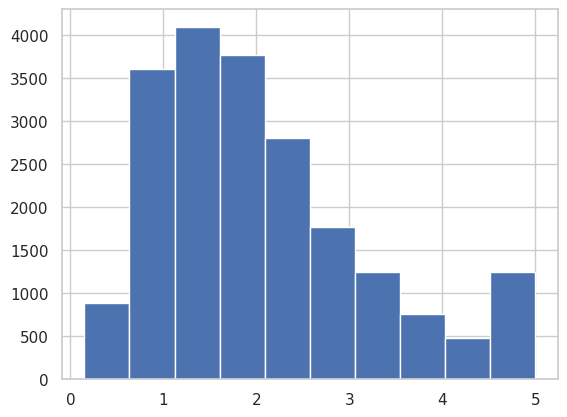

In [21]:
df_cali['MedHouseVal'].hist()

## 4. Detecção de Anomalias
Em segurança (como na deteção de fraudes de cartão ou falhas industriais), o foco não é prever uma classe, mas sim **encontrar pontos que estão completamente isolados do grupo**.

Como o KNN calcula distâncias, ele é perfeito para isso!
1. Calculamos a distância média de cada ponto para os seus vizinhos.
2. Plotamos um **Histograma da Distribuição de Distâncias**.
3. A esmagadora maioria dos dados terá distâncias pequenas. A cauda longa do histograma irá revelar os *outliers* isolados. Estabelecemos um "corte visual" (Threshold).

In [22]:
# Criando um dataset "normal" (clusters densos) e injetando anomalias (ruído)
X_normal, _ = make_blobs(n_samples=400, centers=2, cluster_std=0.8, random_state=42)
anomalias = np.random.uniform(low=-8, high=8, size=(15, 2)) # 15 pontos aleatórios espalhados
X_dados = np.vstack([X_normal, anomalias])

X_dados = StandardScaler().fit_transform(X_dados)

In [23]:
# Usando NearestNeighbors (modelo não-supervisionado do Scikit)
nn = NearestNeighbors(n_neighbors=5)
nn.fit(X_dados)

NearestNeighbors()

In [24]:
# Obtendo as distâncias
distancias, indices = nn.kneighbors(X_dados)
score_anomalia = distancias.mean(axis=1)

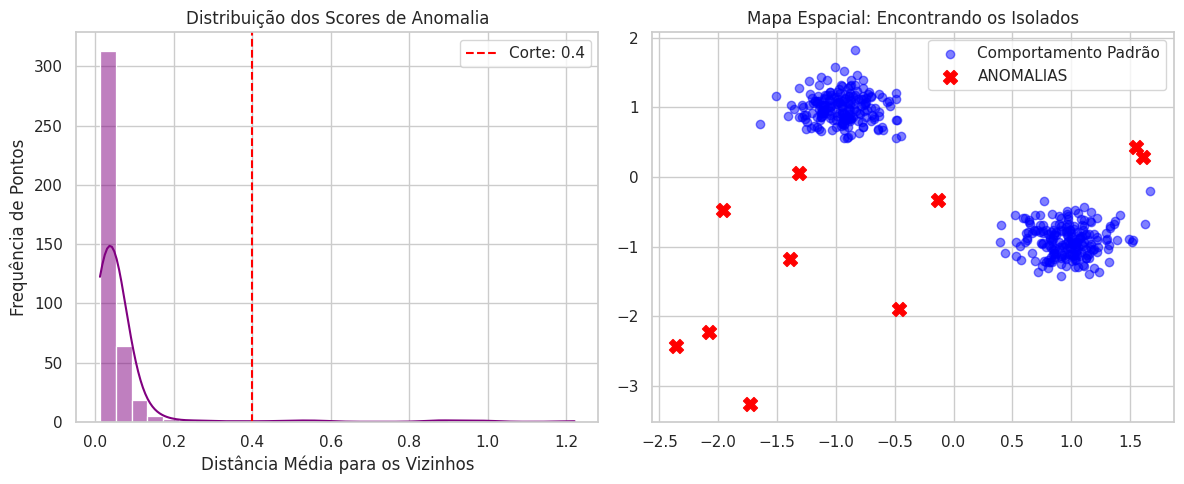

In [26]:
# VISUALIZAÇÃO DA DISTRIBUIÇÃO (HISTOGRAMA)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(score_anomalia, bins=30, kde=True, color='purple')
plt.title('Distribuição dos Scores de Anomalia')
plt.xlabel('Distância Média para os Vizinhos')
plt.ylabel('Frequência de Pontos')

# Definindo o limite visual com base no histograma
threshold_corte = 0.4
plt.axvline(threshold_corte, color='red', linestyle='--', label=f'Corte: {threshold_corte}')
plt.legend()

# Filtrando quem é anomalia
mascara_anomalias = score_anomalia > threshold_corte

# Plotando os dados espacialmente
plt.subplot(1, 2, 2)
plt.scatter(X_dados[~mascara_anomalias, 0], X_dados[~mascara_anomalias, 1], c='blue', alpha=0.5, label='Comportamento Padrão')
plt.scatter(X_dados[mascara_anomalias, 0], X_dados[mascara_anomalias, 1], c='red', marker='X', s=100, label='ANOMALIAS')
plt.title('Mapa Espacial: Encontrando os Isolados')
plt.legend()

plt.tight_layout()
plt.show()

## 5. Consumo de Memória
Lembra-se que chamamos o KNN de "Lazy Learner"? O preço dessa preguiça na fase de treino chega na fase em que colocamos o modelo em produção (Deploy).

Modelos paramétricos, como a Regressão Logística, processam os dados, extraem uma equação matemática (pesos) e deixam fora o *dataset*. O modelo final é levíssimo.
O KNN, por não construir uma equação, **guarda o dataset de treino inteiro dentro da sua própria estrutura de memória**.

Vamos provar isto comparando o tamanho em Bytes de um modelo KNN versus uma Regressão Logística, ambos treinados com a mesma quantidade de dados.

In [27]:
# Gerando um dataset massivo (100.000 linhas)
X_gigante, y_gigante = make_blobs(n_samples=100000, centers=2, random_state=42)

X_train_gig, X_test_gig, y_train_gig, y_test_gig = train_test_split(X_gigante, y_gigante, test_size=0.2, random_state=42)

In [33]:
# Treinando KNN
modelo_knn = KNeighborsClassifier(n_neighbors=3, algorithm='auto')
modelo_knn.fit(X_train_gig, y_train_gig)

KNeighborsClassifier(n_neighbors=3)

In [34]:
# Treinando Regressão Logística
modelo_log = LogisticRegression()
modelo_log.fit(X_train_gig, y_train_gig)

LogisticRegression()

In [35]:
# Serializando (salvando) os modelos para medir exatamente o espaço que ocupam em disco/memória
tamanho_knn = len(pickle.dumps(modelo_knn))
tamanho_log = len(pickle.dumps(modelo_log))

In [36]:
print("--- CONSUMO DE MEMÓRIA DO MODELO TREINADO ---")
print(f"Dados inseridos: 100.000 amostras.")
print(f"Tamanho da Regressão Logística: {tamanho_log} Bytes (Apenas a equação)")
print(f"Tamanho do KNN: {tamanho_knn:,} Bytes (O dataset inteiro memorizado!)")
print(f"\nO KNN consome aproximadamente {(tamanho_knn/tamanho_log):.0f} vezes mais memória neste caso!")

--- CONSUMO DE MEMÓRIA DO MODELO TREINADO ---
Dados inseridos: 100.000 amostras.
Tamanho da Regressão Logística: 731 Bytes (Apenas a equação)
Tamanho do KNN: 2,823,286 Bytes (O dataset inteiro memorizado!)

O KNN consome aproximadamente 3862 vezes mais memória neste caso!


In [37]:
import time
print(f"Iniciando predição para {len(X_test_gig)} novos registros...\n")

# --- Medindo o tempo da Regressão Logística ---
inicio_log = time.perf_counter()
modelo_log.predict(X_test_gig) # Aplica apenas a equação (rápido)
fim_log = time.perf_counter()
tempo_log = fim_log - inicio_log

# --- Medindo o tempo do KNN ---
inicio_knn = time.perf_counter()
modelo_knn.predict(X_test_gig) # Calcula distâncias contra 80.000 pontos para cada um dos 20.000 testes (lento)
fim_knn = time.perf_counter()
tempo_knn = fim_knn - inicio_knn

# --- Resultados ---
print(f"⏱️ Tempo Regressão Logística: {tempo_log:.4f} segundos")
print(f"⏱️ Tempo KNN: {tempo_knn:.4f} segundos")

if tempo_log > 0:
    print(f"\nO KNN foi aproximadamente {(tempo_knn/tempo_log):.0f} vezes MAIS LENTO para responder!")

Iniciando predição para 20000 novos registros...

⏱️ Tempo Regressão Logística: 0.0009 segundos
⏱️ Tempo KNN: 0.3599 segundos

O KNN foi aproximadamente 398 vezes MAIS LENTO para responder!
